# 06 – Advanced Models: Gradient Boosting (XGBoost)

This notebook evaluates XGBoost as a more expressive alternative to the tree-based models from Notebooks 04–05. Two questions drive the analysis:

1. Does default XGBoost outperform the best *tuned* traditional model (Random Forest, Notebook 05)?
2. Does tuning XGBoost further improve upon that?

Results are compiled into a full cross-model comparison table to identify the strongest ML model before the neural network comparison in Notebook 07.


## Imports


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix,
    classification_report
)
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier

BASE_DIR = Path("..").resolve()
PROCESSED_DIR = BASE_DIR / "data" / "processed"

## Load Processed Data

Preprocessed features and binary target labels loaded from Notebook 02 outputs.

In [2]:
X = pd.read_csv(PROCESSED_DIR / "cell2celltrain_processed.csv")
y = pd.read_csv(PROCESSED_DIR / "cell2celltrain_target.csv").squeeze("columns")

print("Features shape:", X.shape)
print("Target shape:  ", y.shape)

Features shape: (51047, 50)
Target shape:   (51047,)


## Train-Test Split

80/20 stratified split (`random_state=42`), consistent with Notebooks 03–05.


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Training set:", X_train.shape)
print("Test set:    ", X_test.shape)

Training set: (40837, 50)
Test set:     (10210, 50)


## Leakage-Free Resampling via Pipeline Integration

As in Notebook 05, under-sampling is wrapped inside an `imblearn.Pipeline` alongside the model rather than applied as a standalone preprocessing step. This ensures that `RandomUnderSampler` is fitted and applied exclusively within each training fold during cross-validation, and the validation fold always retains the original class distribution. This prevents artificially inflated CV F1 scores that would result from resampling the validation fold.

In [4]:
# Under-sampling is now handled inside each model's ImbPipeline — no standalone resampling step needed.
print("Under-sampling will be applied within each CV fold via ImbPipeline.")

Under-sampling will be applied within each CV fold via ImbPipeline.


## Evaluation Function

Same function used across Notebooks 03–05 for consistent metric computation.

In [5]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    precision = precision_score(y_test, y_pred, zero_division=0)
    recall    = recall_score(y_test, y_pred, zero_division=0)
    f1        = f1_score(y_test, y_pred, zero_division=0)
    roc_auc   = roc_auc_score(y_test, y_prob)
    cm        = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    print(f"=== {name} ===")
    print(f"  Precision : {precision:.4f}")
    print(f"  Recall    : {recall:.4f}")
    print(f"  F1-score  : {f1:.4f}")
    print(f"  ROC-AUC   : {roc_auc:.4f}")
    print(f"  Confusion Matrix:")
    print(f"    TN={tn}  FP={fp}")
    print(f"    FN={fn}  TP={tp}")
    print()

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"], zero_division=0))

    return {
        "Precision": round(precision, 4),
        "Recall":    round(recall, 4),
        "F1-score":  round(f1, 4),
        "ROC-AUC":   round(roc_auc, 4),
        "Confusion Matrix": cm
    }

## XGBoost — Default Settings

XGBoost is evaluated first at its default hyperparameters to establish an untuned baseline. This allows a controlled comparison: if default XGBoost already outperforms tuned Random Forest, that would indicate a genuine architectural advantage of gradient boosting over bagging on this dataset. If it does not, any subsequent improvement from tuning XGBoost can be attributed to optimisation rather than to the algorithm itself.

XGBoost uses gradient boosting — trees are added sequentially, each correcting the residual errors of the current ensemble. Built-in regularisation parameters (`gamma`, `reg_alpha`, `reg_lambda`) control tree complexity and prevent overfitting, even at default settings. `eval_metric='logloss'` suppresses a default warning and specifies the internal training evaluation metric.

In [6]:
results = {}

pipe_xgb_default = ImbPipeline([
    ("undersample", RandomUnderSampler(random_state=42)),
    ("model", XGBClassifier(random_state=42, eval_metric="logloss"))
])
pipe_xgb_default.fit(X_train, y_train)

results["XGBoost (Default)"] = evaluate_model(
    "XGBoost (Default)", pipe_xgb_default, X_test, y_test
)

=== XGBoost (Default) ===
  Precision : 0.3819
  Recall    : 0.6254
  F1-score  : 0.4742
  ROC-AUC   : 0.6507
  Confusion Matrix:
    TN=4290  FP=2978
    FN=1102  TP=1840


Classification Report:
              precision    recall  f1-score   support

    No Churn       0.80      0.59      0.68      7268
       Churn       0.38      0.63      0.47      2942

    accuracy                           0.60     10210
   macro avg       0.59      0.61      0.58     10210
weighted avg       0.68      0.60      0.62     10210



Default XGBoost achieves F1 of 0.4742 and ROC-AUC of 0.6507. Compared against the tuned Random Forest from Notebook 05 (F1: 0.4874, ROC-AUC: 0.6576), default XGBoost falls below on both primary metrics. This indicates that gradient boosting does not hold a self-evident architectural advantage at default settings — the tuned Random Forest's performance reflects the benefit of optimisation, not solely its ensemble mechanism. Tuning XGBoost is therefore necessary to make a fair architectural comparison.

## Model 2 — XGBoost Tuned

RandomizedSearchCV (50 iterations, 5-fold CV) over key XGBoost parameters: learning rate, tree depth, regularisation (`reg_alpha`, `reg_lambda`), and sampling (`subsample`, `colsample_bytree`). Scoring metric: F1.


In [7]:
pipe_xgb = ImbPipeline([
    ("undersample", RandomUnderSampler(random_state=42)),
    ("model", XGBClassifier(random_state=42, eval_metric="logloss"))
])

param_dist_xgb = {
    "model__n_estimators":     [100, 200, 300, 500],
    "model__max_depth":        [3, 4, 5, 6, 7],
    "model__learning_rate":    [0.01, 0.05, 0.1, 0.2, 0.3],
    "model__subsample":        [0.6, 0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "model__gamma":            [0, 0.1, 0.2, 0.5, 1.0],
    "model__reg_alpha":        [0, 0.1, 0.5, 1.0],
    "model__reg_lambda":       [0.5, 1.0, 1.5, 2.0]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search_xgb = RandomizedSearchCV(
    estimator=pipe_xgb,
    param_distributions=param_dist_xgb,
    n_iter=50,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
search_xgb.fit(X_train, y_train)

print("Best params:", search_xgb.best_params_)
print("Best CV F1: ", round(search_xgb.best_score_, 4))

results["XGBoost (Tuned)"] = evaluate_model(
    "XGBoost (Tuned)", search_xgb.best_estimator_, X_test, y_test
)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params: {'model__subsample': 0.8, 'model__reg_lambda': 1.0, 'model__reg_alpha': 0.1, 'model__n_estimators': 200, 'model__max_depth': 4, 'model__learning_rate': 0.05, 'model__gamma': 1.0, 'model__colsample_bytree': 1.0}
Best CV F1:  0.496
=== XGBoost (Tuned) ===
  Precision : 0.3887
  Recall    : 0.6601
  F1-score  : 0.4893
  ROC-AUC   : 0.6688
  Confusion Matrix:
    TN=4214  FP=3054
    FN=1000  TP=1942


Classification Report:
              precision    recall  f1-score   support

    No Churn       0.81      0.58      0.68      7268
       Churn       0.39      0.66      0.49      2942

    accuracy                           0.60     10210
   macro avg       0.60      0.62      0.58     10210
weighted avg       0.69      0.60      0.62     10210



Tuning improved XGBoost across all metrics: F1 increased from 0.4742 to 0.4893, ROC-AUC from 0.6507 to 0.6688, and recall from 0.6254 to 0.6601. The selected configuration uses a relatively low learning rate (0.05) with 200 estimators, a shallow maximum depth (4), and `gamma=1.0` — a substantial tree-splitting penalty that enforces conservatism in the boosting process. The combination of `subsample=0.8` and `colsample_bytree=1.0` reduces variance via row subsampling whilst retaining all features at each tree. Together, these parameters produce a regularised, shallow ensemble that generalises better than the default configuration.

## XGBoost: Default vs Tuned


In [8]:
xgb_comparison = pd.DataFrame({
    name: {m: results[name][m] for m in ["Precision", "Recall", "F1-score", "ROC-AUC"]}
    for name in ["XGBoost (Default)", "XGBoost (Tuned)"]
}).T

print("=== XGBoost: Default vs Tuned ===")
print(xgb_comparison.to_string())

=== XGBoost: Default vs Tuned ===
                   Precision  Recall  F1-score  ROC-AUC
XGBoost (Default)     0.3819  0.6254    0.4742   0.6507
XGBoost (Tuned)       0.3887  0.6601    0.4893   0.6688


Tuning XGBoost yielded consistent improvements across all metrics (+0.017 F1, +0.019 ROC-AUC, +0.038 recall). The gain is meaningful but not dramatic, suggesting that the default XGBoost configuration is already reasonably well-suited to this task and that the marginal gains from tuning arise from fine-tuning regularisation strength and tree depth rather than from structural changes to the model.

## Full Model Comparison

Load tuned Notebook 05 results and combine with XGBoost:


In [9]:
# Load tuned baseline results from Notebook 05
nb05_results = pd.read_csv(PROCESSED_DIR / "notebook05_tuned_results.csv", index_col=0)

# Build XGBoost results as a DataFrame
xgb_results = pd.DataFrame({
    name: {m: results[name][m] for m in ["Precision", "Recall", "F1-score", "ROC-AUC"]}
    for name in ["XGBoost (Default)", "XGBoost (Tuned)"]
}).T

# Combine
full_comparison = pd.concat([nb05_results, xgb_results])

print("=== Full Model Comparison ===")
print(full_comparison.to_string())

# Save for reference in Notebook 07
full_comparison.to_csv(PROCESSED_DIR / "notebook06_full_results.csv")
print("\nResults saved to:", PROCESSED_DIR / "notebook06_full_results.csv")

=== Full Model Comparison ===
                             Precision  Recall  F1-score  ROC-AUC
Logistic Regression (Tuned)     0.3599  0.5744    0.4425   0.6122
Decision Tree (Tuned)           0.3756  0.5421    0.4437   0.6243
Random Forest (Tuned)           0.3763  0.6917    0.4874   0.6576
XGBoost (Default)               0.3819  0.6254    0.4742   0.6507
XGBoost (Tuned)                 0.3887  0.6601    0.4893   0.6688

Results saved to: /Users/abbasq/Uni/third-year/IP/data/processed/notebook06_full_results.csv


## Confusion Matrices

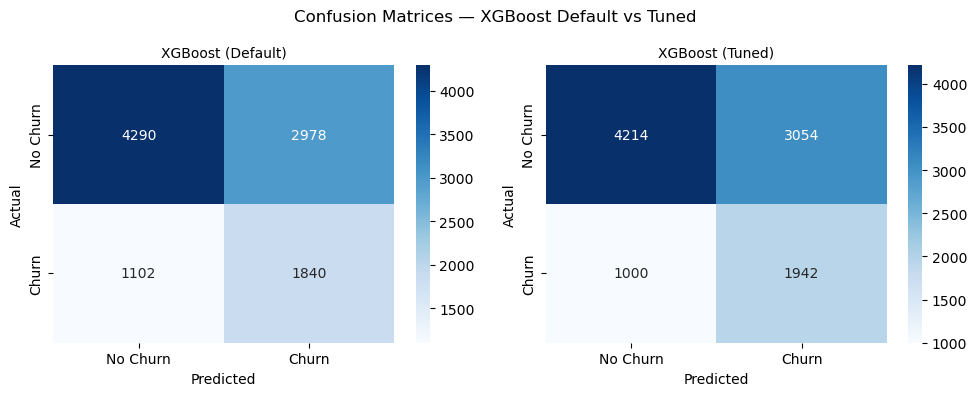

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (name, metrics) in zip(axes, results.items()):
    cm = metrics["Confusion Matrix"]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=["No Churn", "Churn"],
                yticklabels=["No Churn", "Churn"])
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices — XGBoost Default vs Tuned", fontsize=12)
plt.tight_layout()
plt.show()

## Key Observations and Model Selection

**Architectural comparison — default XGBoost vs tuned Random Forest:** Default XGBoost (F1: 0.4742, ROC-AUC: 0.6507) falls below tuned Random Forest (F1: 0.4874, ROC-AUC: 0.6576) on both primary metrics. This confirms that gradient boosting does not hold an inherent architectural advantage over well-tuned bagging on this dataset — the Random Forest's lead at this stage reflects the benefit of systematic tuning rather than any fundamental weakness of XGBoost.

**Effect of tuning XGBoost:** Tuning closes this gap and reverses it. XGBoost (Tuned) achieves F1 of 0.4893 and ROC-AUC of 0.6688 — surpassing tuned Random Forest on both measures. The improvement from default to tuned XGBoost (+0.015 F1, +0.018 ROC-AUC) is larger than the default XGBoost deficit relative to tuned Random Forest (-0.013 F1, -0.007 ROC-AUC), confirming that the search found a genuinely superior configuration.

**Random Forest (Tuned) vs XGBoost (Tuned):** Random Forest retains the highest raw recall (0.692 vs 0.660) — identifying 93 more churners — but XGBoost leads on F1 (+0.002) and ROC-AUC (+0.011). In the context of churn prediction, where the cost of missed churners (false negatives) is high, the recall difference warrants consideration. However, F1 is the primary metric adopted for this project as it jointly balances precision and recall, and by that measure XGBoost (Tuned) is the stronger model.

**XGBoost (Tuned) is selected as the best-performing ML model overall.** It is carried forward to Notebook 07 as the ML benchmark for comparison with the neural network, and is the model subjected to SHAP-based feature importance analysis in Notebook 08.